# Passenger Arrival Rate

**Research question:** How does passenger arrival probability affect waiting time, congestion, and throughput in the airport security system?

This experiment varies the passenger arrival probability while keeping the number of checkpoints, queue capacity, and service duration fixed.

The experiment examines whether increasing passenger demand causes longer queues and waiting times, and whether the security system reaches its service-capacity limit.

## Setup

Install the project dependencies using `python -m pip install -r requirements.txt`. Select that Python environment as the notebook kernel. Run this notebook from the project root or its `notebooks` directory.

The model is imported from `src`; its implementation is not duplicated here. Restart the kernel and run all cells after changing a model file.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = next(
    (
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "src" / "model.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Start the notebook from the project root or the notebooks directory."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.Model import AirportSecurityModel

## Experimental Design

- Arrival probability: 0.2, 0.3, 0.4, and 0.5 per time step.
- Queue capacity: 10 waiting passengers per checkpoint
- Checkpoints: 2.
- Service duration: Fixed at 4 time steps.
- Processing-time variation: 0.
- Simulation length: 5,000 time steps.
- Seeds: 0 through 29.

The experiment changes only the passenger arrival probability while keeping the number of checkpoints, queue capacity, service duration, and simulation length fixed. Each arrival-probability setting is repeated 30 times using seeds 0 through 29.

With two checkpoints and a fixed service duration of four time steps, the nominal service capacity is 0.5 passengers per time step. The tested arrival probabilities therefore range from well below this service capacity to the nominal capacity limit.

Completed-passenger mean waiting time is calculated only for passengers who finish screening within the observation period. Internal and external queue lengths are measured separately. Throughput rate is calculated as completed passengers divided by simulation steps, and unfinished passengers are recorded at the end of each run.

In [10]:
arrival_rates = [0.2, 0.3, 0.4, 0.5]
seeds = range(30)

base_parameters = {
    "queue_capacity": 10,
    "num_checkpoints": 2,
    "processing_time": 4,
    "simulation_steps": 5000,
    "processing_time_variation": 0,
}

print("Arrival probabilities:", arrival_rates)
print("Number of repetitions:", len(seeds))

Arrival probabilities: [0.2, 0.3, 0.4, 0.5]
Number of repetitions: 30


In [11]:
experiment_results = []

for arrival_rate in arrival_rates:
    for seed in seeds:

        model = AirportSecurityModel(
            **base_parameters,
            arrival_rate=arrival_rate,
            seed=seed
        )

        model.run()
        results = model.get_results()

        # Mean internal queue length during the simulation
        mean_internal_queue = np.mean(model.queue_length_history)

        # Mean external queue length during the simulation
        mean_external_queue = np.mean(model.external_waiting_history)

        # Throughput rate:
        # completed passengers divided by simulation steps
        throughput_rate = (
            len(model.completed_passengers) / model.simulation_steps
        )

        # Unfinished passengers at the end:
        # internal waiting + external waiting + still in service
        unfinished_passengers = (
            sum(len(queue) for queue in model.queues)
            + len(model.external_waiting)
            + sum(passenger is not None for passenger in model.in_service)
        )

        experiment_results.append({
            "arrival_rate": arrival_rate,
            "seed": seed,
            "average_waiting_time": results["average_waiting_time"],
            "mean_internal_queue": mean_internal_queue,
            "mean_external_queue": mean_external_queue,
            "throughput_rate": throughput_rate,
            "unfinished_passengers": unfinished_passengers
        })

print("Total runs:", len(experiment_results))

Total runs: 120


In [12]:
summary_results = []

for arrival_rate in arrival_rates:

    runs = [
        result
        for result in experiment_results
        if result["arrival_rate"] == arrival_rate
    ]

    waiting_times = np.array([
        result["average_waiting_time"]
        for result in runs
    ])

    valid_waiting_times = waiting_times[~np.isnan(waiting_times)]

    internal_queues = np.array([
        result["mean_internal_queue"]
        for result in runs
    ])

    external_queues = np.array([
        result["mean_external_queue"]
        for result in runs
    ])

    throughputs = np.array([
        result["throughput_rate"]
        for result in runs
    ])

    unfinished = np.array([
        result["unfinished_passengers"]
        for result in runs
    ])

    summary_results.append({
        "arrival_rate": arrival_rate,

        "mean_wait": np.mean(valid_waiting_times),
        "sd_wait": np.std(valid_waiting_times, ddof=1),

        "mean_internal_queue": np.mean(internal_queues),
        "sd_internal_queue": np.std(internal_queues, ddof=1),

        "mean_external_queue": np.mean(external_queues),
        "sd_external_queue": np.std(external_queues, ddof=1),

        "mean_throughput": np.mean(throughputs),
        "sd_throughput": np.std(throughputs, ddof=1),

        "mean_unfinished": np.mean(unfinished),
        "sd_unfinished": np.std(unfinished, ddof=1),

        "completed_runs": len(valid_waiting_times)
    })

for result in summary_results:

    print(f"Arrival probability: {result['arrival_rate']}")
    print(
        f"  Runs with completed passengers: "
        f"{result['completed_runs']}/{len(seeds)}"
    )

    print(
        f"  Completed-passenger mean wait: "
        f"{result['mean_wait']:.2f} time steps"
    )

    print(
        f"  SD of run mean waits: "
        f"{result['sd_wait']:.2f} time steps"
    )

    print(
        f"  Mean internal queue: "
        f"{result['mean_internal_queue']:.2f} passengers"
    )

    print(
        f"  Mean external queue: "
        f"{result['mean_external_queue']:.2f} passengers"
    )

    print(
        f"  Mean throughput rate: "
        f"{result['mean_throughput']:.3f} passengers per time step"
    )

    print(
        f"  Mean unfinished passengers at end: "
        f"{result['mean_unfinished']:.2f}"
    )

    print()

Arrival probability: 0.2
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 0.23 time steps
  SD of run mean waits: 0.04 time steps
  Mean internal queue: 0.05 passengers
  Mean external queue: 0.00 passengers
  Mean throughput rate: 0.200 passengers per time step
  Mean unfinished passengers at end: 0.73

Arrival probability: 0.3
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 0.67 time steps
  SD of run mean waits: 0.08 time steps
  Mean internal queue: 0.20 passengers
  Mean external queue: 0.00 passengers
  Mean throughput rate: 0.300 passengers per time step
  Mean unfinished passengers at end: 1.43

Arrival probability: 0.4
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 1.96 time steps
  SD of run mean waits: 0.25 time steps
  Mean internal queue: 0.78 passengers
  Mean external queue: 0.00 passengers
  Mean throughput rate: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.37

Arrival pr

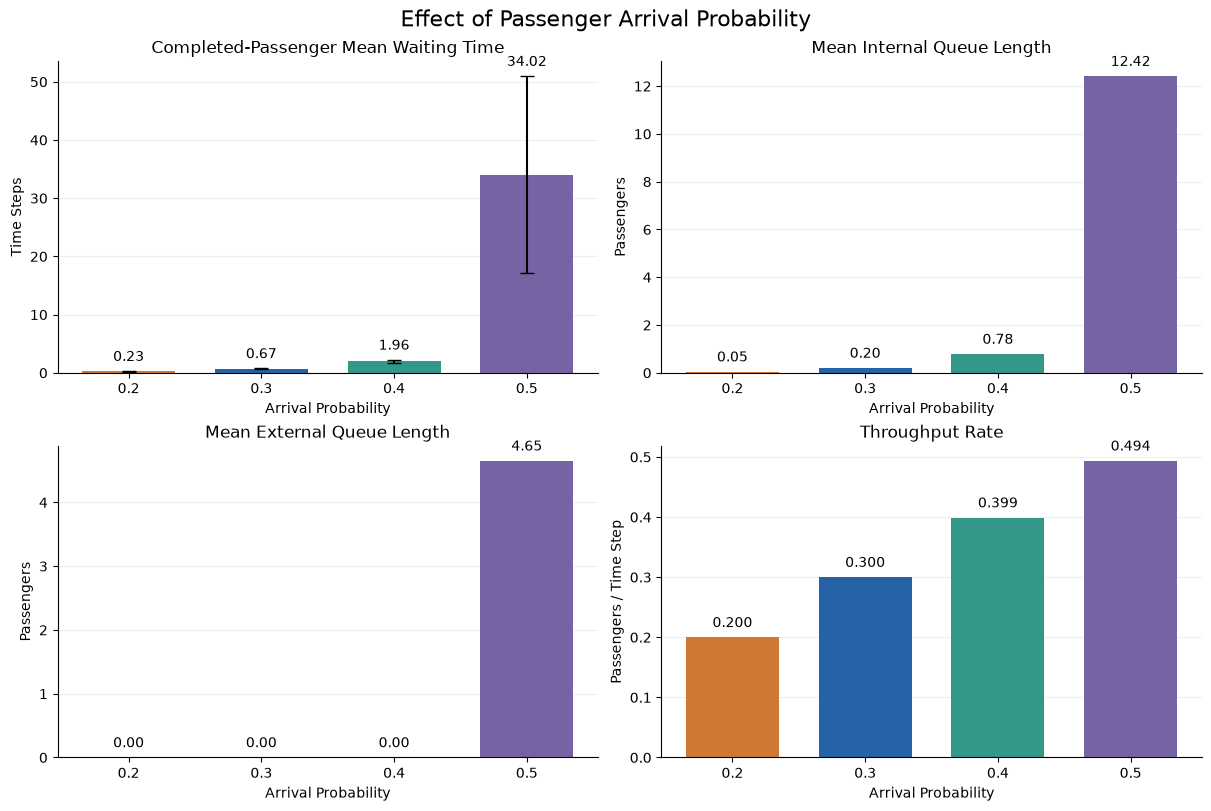

In [14]:
arrival_probs = [
    result["arrival_rate"]
    for result in summary_results
]

mean_waits = np.array([
    result["mean_wait"]
    for result in summary_results
])

sd_waits = np.array([
    result["sd_wait"]
    for result in summary_results
])

mean_internal = np.array([
    result["mean_internal_queue"]
    for result in summary_results
])

mean_external = np.array([
    result["mean_external_queue"]
    for result in summary_results
])

throughput = np.array([
    result["mean_throughput"]
    for result in summary_results
])

colors = ["#CE7833", "#2563A6", "#349889", "#7563A3"]

x = np.arange(len(arrival_probs))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
fig.suptitle("Effect of Passenger Arrival Probability", fontsize=16)

bars = axes[0, 0].bar(
    x,
    mean_waits,
    yerr=sd_waits,
    capsize=5,
    color=colors,
    width=0.7
)
axes[0, 0].set_title("Completed-Passenger Mean Waiting Time")
axes[0, 0].set_xlabel("Arrival Probability")
axes[0, 0].set_ylabel("Time Steps")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(arrival_probs)
axes[0, 0].grid(axis="y", alpha=0.2)
axes[0, 0].set_axisbelow(True)
axes[0, 0].bar_label(
    bars,
    labels=[f"{v:.2f}" for v in mean_waits],
    padding=5
)

bars = axes[0, 1].bar(
    x,
    mean_internal,
    color=colors,
    width=0.7
)
axes[0, 1].set_title("Mean Internal Queue Length")
axes[0, 1].set_xlabel("Arrival Probability")
axes[0, 1].set_ylabel("Passengers")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(arrival_probs)
axes[0, 1].grid(axis="y", alpha=0.2)
axes[0, 1].set_axisbelow(True)
axes[0, 1].bar_label(
    bars,
    labels=[f"{v:.2f}" for v in mean_internal],
    padding=5
)
bars = axes[1, 0].bar(
    x,
    mean_external,
    color=colors,
    width=0.7
)
axes[1, 0].set_title("Mean External Queue Length")
axes[1, 0].set_xlabel("Arrival Probability")
axes[1, 0].set_ylabel("Passengers")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(arrival_probs)
axes[1, 0].grid(axis="y", alpha=0.2)
axes[1, 0].set_axisbelow(True)
axes[1, 0].bar_label(
    bars,
    labels=[f"{v:.2f}" for v in mean_external],
    padding=5
)

bars = axes[1, 1].bar(
    x,
    throughput,
    color=colors,
    width=0.7
)
axes[1, 1].set_title("Throughput Rate")
axes[1, 1].set_xlabel("Arrival Probability")
axes[1, 1].set_ylabel("Passengers / Time Step")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(arrival_probs)
axes[1, 1].grid(axis="y", alpha=0.2)
axes[1, 1].set_axisbelow(True)
axes[1, 1].bar_label(
    bars,
    labels=[f"{v:.3f}" for v in throughput],
    padding=5
)

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()

## Reading the Comparisons

As passenger arrival probability increases, the system becomes more congested. From 0.2 to 0.4, completed-passenger mean waiting time increases gradually from 0.23 to 1.96 time steps, while mean internal queue length increases from 0.05 to 0.78 passengers. The mean external queue remains close to zero over these three scenarios.

A much larger change occurs at an arrival probability of 0.5. Mean waiting time increases sharply to 34.02 time steps and mean internal queue length rises to 12.42 passengers. An external queue also appears, with a mean length of 4.65 passengers. This indicates that the system experiences substantial congestion under the highest arrival demand tested.

Throughput increases with arrival probability, from 0.200 passengers per time step at 0.2 to 0.494 at 0.5. However, the sharp increases in waiting time and queue lengths at 0.5 show that the higher throughput is accompanied by much greater congestion.

Overall, the comparisons show a clear change in system behaviour between arrival probabilities of 0.4 and 0.5.

## Interpretation and Limitations

The results suggest that higher passenger arrival probability increases congestion in the security system. At lower arrival probabilities, the two checkpoints can handle the incoming passengers with relatively short waiting times and little external waiting. When the arrival probability reaches 0.5, waiting time and queue lengths increase sharply.

The large change between arrival probabilities of 0.4 and 0.5 suggests that the system is approaching its service-capacity limit. However, only four arrival probabilities are tested, so the exact point at which congestion begins cannot be identified from this experiment.

Mean waiting time is calculated only for passengers who complete screening within the 5,000-step simulation. Passengers who are still waiting or in service at the end are not included in this waiting-time measure. Therefore, under high demand, the reported mean waiting time may not fully represent all arriving passengers.

The experiment also assumes two checkpoints, a queue capacity of 10 passengers per checkpoint, and a fixed service duration of 4 time steps. Changing these parameters may produce different results.

The simulations begin with an empty system and no warm-up period is removed. Therefore, the results describe the behaviour of this model under the selected assumptions rather than directly representing a real airport security system.